# Sample WSI Viewer (Visium / Visium HD / Xenium)

Load metadata, pick one sample per technology (prefer kidney, human only), then show a random spot patch and a WSI thumbnail. Edit the paths below if your data lives elsewhere.


In [1]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from PIL import Image, ImageFile

try:
    import openslide
    HAS_OSLIDE = True
except Exception:
    HAS_OSLIDE = False

# allow very large WSIs (PIL decompression bomb guard)
Image.MAX_IMAGE_PIXELS = None
ImageFile.LOAD_TRUNCATED_IMAGES = True
warnings.simplefilter('ignore', Image.DecompressionBombWarning)

# Paths (edit for your environment)
meta_path = Path('/proj/berzelius-2025-380/storage/hest1k/HEST_v1_1_0.csv')
st_path = Path('/proj/berzelius-2025-380/storage/hest1k/st')
wsi_root = Path('/proj/berzelius-2025-380/storage/hest1k/wsis')

# Load metadata and restrict to human
meta_df = pd.read_csv(meta_path)
meta_df = meta_df[meta_df['species'] == 'Homo sapiens']

TECHS = ['Visium', 'Visium HD', 'Xenium']


In [14]:
def pick_samples(df, prefer_kidney=True):
    picks = {}
    for tech in TECHS:
        kidney_pool = df[(df['organ'].str.lower() == 'kidney') & df['st_technology'].str.contains(tech, case=False, na=False)] if prefer_kidney else pd.DataFrame()
        pool = kidney_pool if (prefer_kidney and not kidney_pool.empty) else df[df['st_technology'].str.contains(tech, case=False, na=False)]
        pool = pool[pool['id'].apply(lambda x: (st_path / ('%s.h5ad' % x)).exists())]
        if pool.empty:
            continue
        row = pool.sample(1, random_state=random.randint(0, 10_000)).iloc[0]
        if prefer_kidney and kidney_pool.empty:
            print('No kidney sample for %s; picked organ=%s instead' % (tech, row.get('organ')))
        picks[tech] = row
    return picks

samples = pick_samples(meta_df, prefer_kidney=True)
samples


No kidney sample for Visium HD; picked organ=Bowel instead


{'Visium': dataset_title              Genome-wide Spatial Expression Profiling in Fo...
 id                                                                   NCBI539
 image_filename                                                   NCBI539.tif
 organ                                                                 Kidney
 disease_state                                                        Treated
 oncotree_code                                                            NaN
 species                                                         Homo sapiens
 patient                                                                  NaN
 st_technology                                                         Visium
 data_publication_date                                              15-Oct-21
 license                                                                CC BY
 study_link                         https://pubmed.ncbi.nlm.nih.gov/36776149/
 download_page_link1                                  

In [15]:
def load_adata(sample_id):
    path = st_path / ('%s.h5ad' % sample_id)
    if not path.exists():
        raise FileNotFoundError(path)
    return sc.read_h5ad(path)

def find_wsi(sample_id):
    for ext in ['.tif', '.tiff', '.png']:
        cand = wsi_root / ('%s%s' % (sample_id, ext))
        if cand.exists():
            return cand
    return None

def load_slide(wsi_path):
    if HAS_OSLIDE:
        try:
            return openslide.OpenSlide(str(wsi_path))
        except Exception:
            return None
    return None

def show_random_spot(adata, wsi_path, patch_size=224):
    if 'spatial' not in adata.obsm:
        raise ValueError('obsm["spatial"] missing')
    coords = np.asarray(adata.obsm['spatial'])
    if coords.shape[0] == 0:
        raise ValueError('no spots')
    idx = random.randrange(coords.shape[0])
    cx, cy = coords[idx]
    half = patch_size // 2
    box = (int(cx - half), int(cy - half), int(cx + half), int(cy + half))
    slide = load_slide(wsi_path)
    if slide is not None:
        region = slide.read_region((box[0], box[1]), 0, (patch_size, patch_size)).convert('RGB')
        patch = region
    else:
        img = Image.open(wsi_path).convert('RGB')
        patch = img.crop(box)
    plt.figure(figsize=(4, 4))
    plt.imshow(patch)
    plt.axis('off')
    plt.title('Spot %s @ (%.1f, %.1f)' % (adata.obs_names[idx], cx, cy))
    plt.show()

def show_wsi(wsi_path, max_side=2048):
    slide = load_slide(wsi_path)
    if slide is not None:
        w, h = slide.dimensions
        scale = min(max_side / max(w, h), 1.0)
        thumb = slide.get_thumbnail((int(w * scale), int(h * scale))).convert('RGB')
    else:
        img = Image.open(wsi_path).convert('RGB')
        w, h = img.size
        scale = min(max_side / max(w, h), 1.0)
        new_size = (int(w * scale), int(h * scale))
        thumb = img.resize(new_size)
    plt.figure(figsize=(8, 8))
    plt.imshow(thumb)
    plt.axis('off')
    plt.title('WSI: %s (scaled %.3fx)' % (wsi_path.name, scale))
    plt.show()


Tech: Visium | Sample: NCBI539 | Organ: Kidney


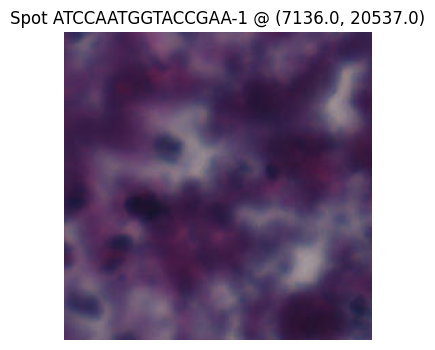

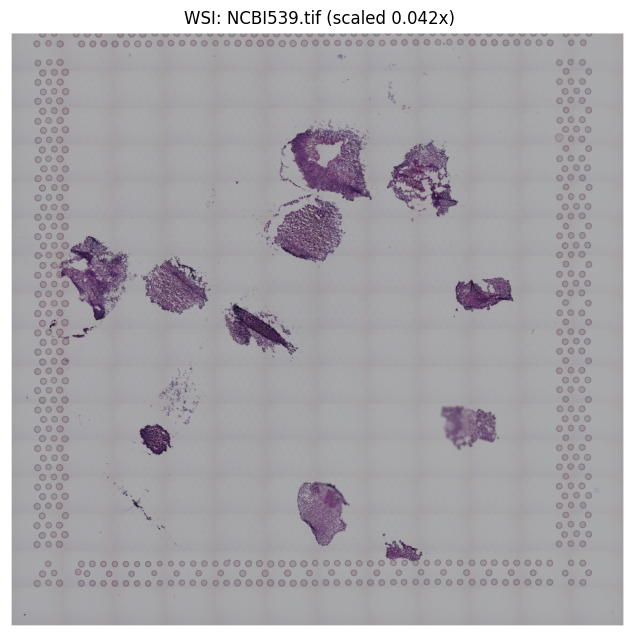

Tech: Visium HD | Sample: TENX128 | Organ: Bowel


/home/x_felco/workspace/Stem_stomics/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
TIFFFetchDirectory: Sanity check on directory count failed, this is probably not a valid IFD offset.
TIFFReadDirectory: Failed to read directory at offset 1551250048.


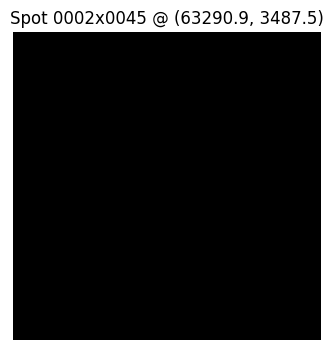

TIFFFetchDirectory: Sanity check on directory count failed, this is probably not a valid IFD offset.
TIFFReadDirectory: Failed to read directory at offset 1551250048.


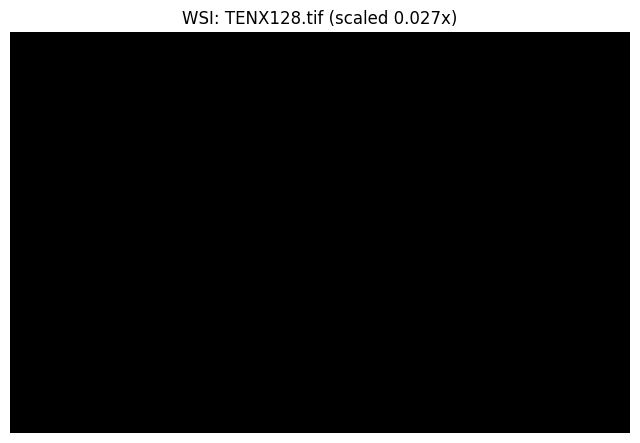

Tech: Xenium | Sample: TENX106 | Organ: Kidney


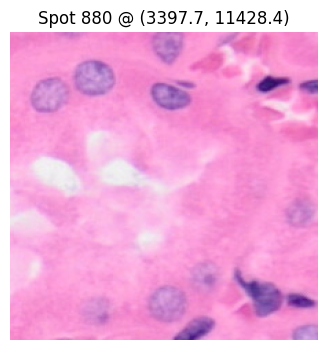

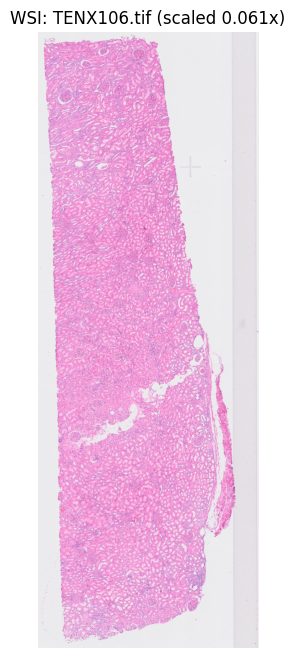

In [16]:
# Demo: visualize one sample per tech (if available)
for tech, row in samples.items():
    sid = row['id']
    print('Tech: %s | Sample: %s | Organ: %s' % (tech, sid, row.get('organ')))
    adata = load_adata(sid)
    wsi_path = find_wsi(sid)
    if wsi_path is None:
        print('WSI not found for %s' % sid)
        continue
    show_random_spot(adata, wsi_path, patch_size=224)
    show_wsi(wsi_path)


In [ ]:
for i in meta_df['pixel_size_um_estimated'].value_counts().items():
    print(i)

(0.2125, 30)
(0.4555808656036446, 3)
(0.7258062155937507, 2)
(0.1726370145643395, 2)
(0.1725124821070217, 2)
(0.4561000455710958, 2)
(0.1735500035772804, 2)
(0.1737105903140622, 2)
(0.4559265251542138, 2)
(0.45572907, 2)
(0.172116998796193, 2)
(0.7575757575757576, 2)
(0.7579957161665734, 2)
(0.1723349624688854, 2)
(0.5729653938552056, 2)
(0.456621005, 2)
(0.7261229207714892, 2)
(0.725876347, 2)
(0.7571917931280607, 2)
(0.456099156062083, 2)
(0.172057719740261, 2)
(0.7256891297751341, 2)
(0.4570383912248628, 2)
(0.5504631494891538, 2)
(0.4553732173362386, 2)
(0.2737536812559247, 1)
(0.5489885719936994, 1)
(0.5515049560837689, 1)
(0.5497248274475363, 1)
(0.5475531951223623, 1)
(0.5493098076682054, 1)
(1.0100952845377356, 1)
(0.2758612653280433, 1)
(0.275601682789277, 1)
(0.2743003567176105, 1)
(0.2761429516791272, 1)
(0.2778581546753353, 1)
(0.2698993887897075, 1)
(0.6231105460935745, 1)
(0.6228058104398951, 1)
(0.8807797273424983, 1)
(0.9680205118992904, 1)
(0.968174199598342, 1)
(0.906